In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import sqlite3
import json

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv
/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv


# Asignación 3: Diseño, Normalización e Implementación de Base de Datos Relacional

**Dataset:** TMDB 5000 Movie Dataset  
**Herramientas:** Kaggle Notebook, Python, Pandas, SQLite, draw.io  
**Base de datos generada:** `tmdb_normalized.db`

## Objetivo
Transformar datos semi-estructurados en formato CSV/JSON del dataset TMDB en un modelo relacional normalizado, implementar la base de datos en SQLite y ejecutar consultas analíticas.

In [2]:
import pandas as pd
import sqlite3
import ast
from pathlib import Path

input_dir = Path("/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata")

movies_path = input_dir / "tmdb_5000_movies.csv"
credits_path = input_dir / "tmdb_5000_credits.csv"

movies = pd.read_csv(movies_path)
credits = pd.read_csv(credits_path)

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)

display(movies.head(3))
display(credits.head(3))

Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## Análisis inicial de columnas JSON

Al revisar los archivos se observa que algunas columnas contienen listas en formato JSON. Estas columnas no son atómicas porque guardan múltiples valores dentro de una sola celda.

En `movies`, las columnas con valores múltiples son:

- `genres`
- `keywords`
- `production_companies`
- `production_countries`
- `spoken_languages`

En `credits`, las columnas con valores múltiples son:

- `cast`
- `crew`

Estas columnas deben separarse en tablas independientes para cumplir con la Primera Forma Normal.

In [3]:
# Las columnas disponibles en cada archivo

print("Columnas de movies:")
print(movies.columns.tolist())

print("\nColumnas de credits:")
print(credits.columns.tolist())

Columnas de movies:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Columnas de credits:
['movie_id', 'title', 'cast', 'crew']


In [4]:
# Ejemplos de columnas JSON / multivaluadas

json_columns_movies = [
    "genres",
    "keywords",
    "production_companies",
    "production_countries",
    "spoken_languages"
]

json_columns_credits = ["cast", "crew"]

for col in json_columns_movies:
    print(f"\nEjemplo de movies['{col}']:")
    print(movies[col].iloc[0])

for col in json_columns_credits:
    print(f"\nEjemplo de credits['{col}']:")
    print(credits[col].iloc[0][:500], "...")


Ejemplo de movies['genres']:
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Ejemplo de movies['keywords']:
[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]

Ejemplo de movies['production_companies']:
[{"name": "Ingenious Fi

## Diagrama Entidad-Relación (E/R)

El diagrama E/R representa el modelo conceptual del dataset TMDB 5000. La entidad principal es `Movie`, ya que toda la información gira alrededor de las películas.

El análisis inicial muestra que una película puede tener múltiples géneros, palabras clave, compañías productoras, países de producción, lenguajes, actores y miembros del equipo técnico. Por esta razón, varias relaciones son de muchos a muchos (M:N).

Estas relaciones luego serán convertidas en tablas puente durante el modelo relacional.

## Imagen del Diagrama Entidad-Relación

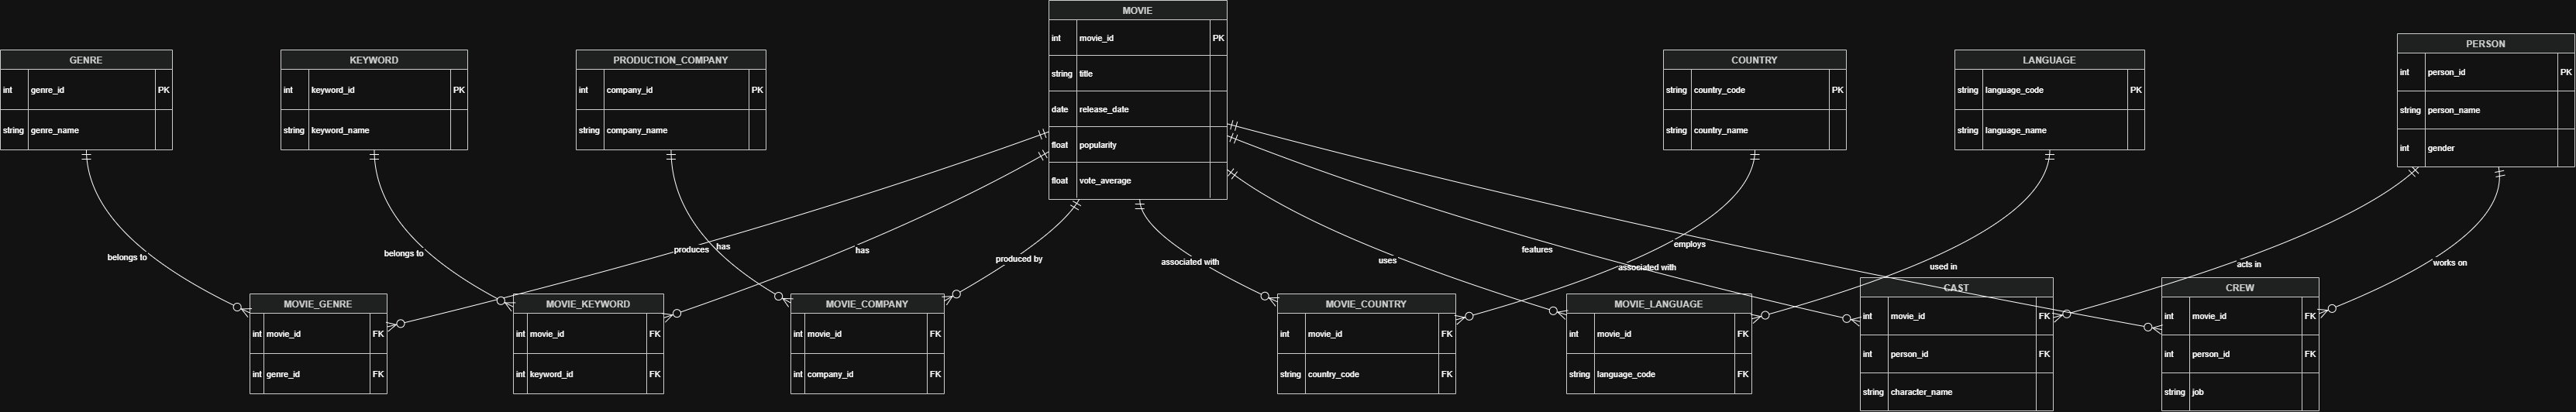

## Traducción del E/R al esquema lógico y normalización

### Primera Forma Normal (1NF)

La Primera Forma Normal establece que cada atributo debe contener valores atómicos, esto queiere decir, solo se encuntra un solo valor por celda. En el dataset original de TMDB, algunas columnas no cumplen con esta regla porque contienen listas en formato JSON dentro de una misma celda.

Las columnas que violan 1NF son:

**En `tmdb_5000_movies.csv`:**
- `genres`
- `keywords`
- `production_companies`
- `production_countries`
- `spoken_languages`

**En `tmdb_5000_credits.csv`:**
- `cast`
- `crew`

Estas columnas contienen grupos repetitivos. Por ejemplo, una misma película puede tener varios géneros, varios idiomas, varios actores y varios miembros del equipo técnico. Si estos valores se dejan dentro de una sola celda, la tabla no está normalizada.

Para cumplir con 1NF, las listas JSON se separan en tablas independientes. Además, se crean tablas puente para mantener la relación entre cada película y sus valores múltiples.

Ejemplo de transformación:

- `genres` se separa en una tabla `genres` y una tabla puente `movie_genres`.
- `spoken_languages` se separa en una tabla `languages` y una tabla puente `movie_spoken_languages`.
- `cast` se separa en una tabla `people` y una tabla puente `movie_cast`.

De esta forma, cada fila contiene un solo valor por atributo y se eliminan los grupos repetitivos del dataset original.

In [5]:
# Columnas que violan 1NF porque contienen listas JSON

print("Ejemplo de genres:")
print(movies["genres"].iloc[0])

print("\nEjemplo de spoken_languages:")
print(movies["spoken_languages"].iloc[0])

print("\nEjemplo de cast:")
print(credits["cast"].iloc[0][:500], "...")

Ejemplo de genres:
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Ejemplo de spoken_languages:
[{"iso_639_1": "en", "name": "English"}, {"iso_639_1": "es", "name": "Espa\u00f1ol"}]

Ejemplo de cast:
[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "c ...


In [6]:
def parse_json_list(value):
    """
    Este bloque convierte una columna tipo JSON/string a una lista de diccionarios.
    Si el valor está vacío o tiene error, devuelve una lista vacía.
    """
    if pd.isna(value):
        return []
    
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
        return []
    except Exception:
        return []

In [7]:
# Aplicación de 1NF a la columna genres

genres_rows = []
movie_genres_rows = []

for _, row in movies.iterrows():
    movie_id = row["id"]
    genres_list = parse_json_list(row["genres"])
    
    for genre in genres_list:
        genres_rows.append({
            "genre_id": genre["id"],
            "genre_name": genre["name"]
        })
        
        movie_genres_rows.append({
            "movie_id": movie_id,
            "genre_id": genre["id"]
        })

genres = pd.DataFrame(genres_rows).drop_duplicates()
movie_genres = pd.DataFrame(movie_genres_rows).drop_duplicates()

print("Tabla genres:")
display(genres.head())

print("Tabla puente movie_genres:")
display(movie_genres.head())

Tabla genres:


,genre_id,genre_name
0,28,Action
1,12,Adventure
2,14,Fantasy
3,878,Science Fiction
9,80,Crime


Tabla puente movie_genres:


,movie_id,genre_id
0,19995,28
1,19995,12
2,19995,14
3,19995,878
4,285,12


### Resultado de 1NF

La columna `genres` originalmente contenía una lista JSON dentro de una sola celda. Para poder cumplir con 1NF, esa lista fue separada en dos tablas:

- `genres`: contiene el catálogo de géneros.
- `movie_genres`: conecta cada película con sus géneros.

Esto elimina los valores multivaluados y permite que cada celda contenga un solo dato. La misma lógica se aplicará a las demás columnas JSON del dataset, como `keywords`, `spoken_languages`, `production_companies`, `production_countries`, `cast` y `crew`.

### Segunda Forma Normal (2NF)

La Segunda Forma Normal establece que la tabla debe estar en 1NF y que todos los atributos no clave deben depender completamente de la llave primaria.

En este diseño, varias relaciones usan tablas puente con llaves compuestas. Un ejemplo de este es la tabla `movie_genres` ya que tiene una llave compuesta formada por:

- `movie_id`
- `genre_id`

Si se guardara `genre_name` directamente en `movie_genres`, habría una dependencia parcial, porque `genre_name` depende únicamente de `genre_id`, no de la combinación completa `movie_id + genre_id`.

Para evitar esta dependencia parcial, se separan los datos descriptivos en tablas maestras o catálogos.

Ejemplo:

- `genres` guarda los datos propios del género.
- `movie_genres` solo guarda la relación entre películas y géneros.

Esta misma lógica se aplica a keywords, compañías productoras, países, lenguajes y personas.

In [8]:
# Ejemplo de problema que 2NF evita:
# En esta tabla mezcla la relación movie_id + genre_id con el dato descriptivo genre_name.

movie_genres_incorrecta = movie_genres.merge(genres, on="genre_id", how="left")

print("Ejemplo de tabla que NO sería ideal en 2NF:")
display(movie_genres_incorrecta.head(10))

print("Tabla catálogo genres:")
display(genres.head())

print("Tabla puente movie_genres:")
display(movie_genres.head())

Ejemplo de tabla que NO sería ideal en 2NF:


,movie_id,genre_id,genre_name
0,19995,28,Action
1,19995,12,Adventure
2,19995,14,Fantasy
3,19995,878,Science Fiction
4,285,12,Adventure
5,285,14,Fantasy
6,285,28,Action
7,206647,28,Action
8,206647,12,Adventure
9,206647,80,Crime


Tabla catálogo genres:


,genre_id,genre_name
0,28,Action
1,12,Adventure
2,14,Fantasy
3,878,Science Fiction
9,80,Crime


Tabla puente movie_genres:


,movie_id,genre_id
0,19995,28
1,19995,12
2,19995,14
3,19995,878
4,285,12


### Resultado de 2NF

La tabla `movie_genres_incorrecta` muestra el problema que se evita con 2NF: repetir `genre_name` en cada relación entre película y género.

La manera correcta para separa la información es de la manera siguiente:

- `genres(genre_id, genre_name)`
- `movie_genres(movie_id, genre_id)`

Así, `genre_name` depende completamente de la llave primaria de `genres`, y `movie_genres` solo representa la relación entre películas y géneros.

Este principio tambien se puede aplicar a:

- `keywords` y `movie_keywords`
- `production_companies` y `movie_production_companies`
- `etc`

### Tercera Forma Normal (3NF)

La Tercera Forma Normal establece que la tabla debe estar en 2NF y que no deben existir dependencias transitivas. Una dependencia transitiva ocurre cuando un atributo no clave depende de otro atributo no clave, en lugar de depender directamente de la llave primaria.

En el dataset TMDB, un ejemplo claro es la información de países y lenguajes. El nombre del país no depende directamente de la película, sino del código del país. De igual forma, el nombre del lenguaje depende del código del lenguaje.

Ejemplo:

- `country_name` depende de `country_code`.
- `language_name` depende de `language_code`.

Por esta razón, estos datos se separan en Master Tables:

- `countries(country_code, country_name)`
- `languages(language_code, language_name)`

Luego, la relación con las películas se guarda mediante tablas puente:

- `movie_production_countries(movie_id, country_code)`
- `movie_spoken_languages(movie_id, language_code)`

De esta forma, se evita repetir el nombre del país o del lenguaje en cada película y se mantiene la dependencia correcta de cada atributo.

In [9]:
# Aplicación de 3NF a production_countries y spoken_languages

countries_rows = []
movie_countries_rows = []

languages_rows = []
movie_languages_rows = []

for _, row in movies.iterrows():
    movie_id = row["id"]
    
    # Países de producción
    for country in parse_json_list(row["production_countries"]):
        countries_rows.append({
            "country_code": country["iso_3166_1"],
            "country_name": country["name"]
        })
        
        movie_countries_rows.append({
            "movie_id": movie_id,
            "country_code": country["iso_3166_1"]
        })
    
    # Lenguajes hablados
    for language in parse_json_list(row["spoken_languages"]):
        languages_rows.append({
            "language_code": language["iso_639_1"],
            "language_name": language["name"]
        })
        
        movie_languages_rows.append({
            "movie_id": movie_id,
            "language_code": language["iso_639_1"]
        })

countries = pd.DataFrame(countries_rows).drop_duplicates()
movie_production_countries = pd.DataFrame(movie_countries_rows).drop_duplicates()

languages = pd.DataFrame(languages_rows).drop_duplicates()
movie_spoken_languages = pd.DataFrame(movie_languages_rows).drop_duplicates()

print("Tabla countries:")
display(countries.head())

print("Tabla puente movie_production_countries:")
display(movie_production_countries.head())

print("Tabla languages:")
display(languages.head())

print("Tabla puente movie_spoken_languages:")
display(movie_spoken_languages.head())

Tabla countries:


,country_code,country_name
0,US,United States of America
1,GB,United Kingdom
16,JM,Jamaica
18,BS,Bahamas
19,DM,Dominica


Tabla puente movie_production_countries:


,movie_id,country_code
0,19995,US
1,19995,GB
2,285,US
3,206647,GB
4,206647,US


Tabla languages:


,language_code,language_name
0,en,English
1,es,Español
3,fr,Français
6,it,Italiano
7,de,Deutsch


Tabla puente movie_spoken_languages:


,movie_id,language_code
0,19995,en
1,19995,es
2,285,en
3,206647,fr
4,206647,en


### Resultado de 3NF

La información de países y lenguajes fue separada para evitar dependencias transitivas. En lugar de guardar `country_name` o `language_name` directamente junto con cada película, se crearon master tables para esos datos.

El diseño correcto queda así:

- `countries(country_code, country_name)`
- `movie_production_countries(movie_id, country_code)`
- `languages(language_code, language_name)`
- `movie_spoken_languages(movie_id, language_code)`

Esto asegura que cada atributo descriptivo dependa directamente de la llave primaria de su propia tabla y no de otro atributo no clave dentro de la tabla de películas.

### BCNF y Cuarta Forma Normal (4NF)

La Forma Normal de Boyce-Codd (BCNF) y la Cuarta Forma Normal (4NF) lo que buscan es eliminar dependencias incorrectas y dependencias multivaluadas independientes.

En el dataset de TMDB, una película puede tener múltiples valores independientes entre sí. Un ejemplo de este es que una película puede tener varios géneros, varios actores, varios lenguajes hablados, varias compañías productoras y varias palabras clave.

Estas relaciones no dependen unas de otras. El hecho de que una película tenga un género específico no determina qué actores aparecen en ella. De igual forma, los actores no determinan los lenguajes hablados ni las compañías productoras.

Si todos estos valores se guardaran en una sola tabla, se producirían combinaciones repetidas e innecesarias entre géneros, actores, lenguajes y compañías. Para evitar esto, cada relación multivaluada se separa en su propia tabla puente.

Ejemplos de tablas puente son:

- `movie_genres`
- `movie_keywords`
- `movie_production_companies`
- `movie_production_countries`
- `movie_spoken_languages`
- `movie_cast`
- `movie_crew`

De esta forma, cada dependencia multivaluada se representa de manera independiente y se reduce la redundancia.

In [10]:
# Primero creamos la tabla movie_cast para demostrar BCNF y 4NF

people_rows = []
movie_cast_rows = []

for _, row in credits.iterrows():
    movie_id = row["movie_id"]
    cast_list = parse_json_list(row["cast"])
    
    for actor in cast_list:
        people_rows.append({
            "person_id": actor.get("id"),
            "person_name": actor.get("name"),
            "gender": actor.get("gender")
        })
        
        movie_cast_rows.append({
            "movie_id": movie_id,
            "person_id": actor.get("id"),
            "character": actor.get("character"),
            "cast_order": actor.get("order")
        })

people = pd.DataFrame(people_rows).drop_duplicates(subset=["person_id"])
movie_cast = pd.DataFrame(movie_cast_rows).drop_duplicates()

print("Tabla puente movie_cast:")
display(movie_cast.head())

Tabla puente movie_cast:


,movie_id,person_id,character,cast_order
0,19995,65731,Jake Sully,0
1,19995,8691,Neytiri,1
2,19995,10205,Dr. Grace Augustine,2
3,19995,32747,Col. Quaritch,3
4,19995,17647,Trudy Chacon,4


In [11]:
# Un ejemplo de problema que 4NF evita:
# Si mezclamos los géneros y los actores en una misma tabla, se generan combinaciones repetidas.

movie_id_example = movies.iloc[0]["id"]
movie_title_example = movies.iloc[0]["title"]

genres_example = movie_genres[movie_genres["movie_id"] == movie_id_example]
cast_example = movie_cast[movie_cast["movie_id"] == movie_id_example].head(5)

combinacion_incorrecta = genres_example.merge(cast_example, on="movie_id", how="inner")

print("Película de ejemplo:", movie_title_example)
print("Cantidad de géneros:", len(genres_example))
print("Cantidad de actores mostrados:", len(cast_example))
print("Filas generadas al mezclarlos:", len(combinacion_incorrecta))

display(combinacion_incorrecta.head(15))

Película de ejemplo: Avatar
Cantidad de géneros: 4
Cantidad de actores mostrados: 5
Filas generadas al mezclarlos: 20


,movie_id,genre_id,person_id,character,cast_order
0,19995,28,65731,Jake Sully,0
1,19995,28,8691,Neytiri,1
2,19995,28,10205,Dr. Grace Augustine,2
3,19995,28,32747,Col. Quaritch,3
4,19995,28,17647,Trudy Chacon,4
5,19995,12,65731,Jake Sully,0
6,19995,12,8691,Neytiri,1
7,19995,12,10205,Dr. Grace Augustine,2
8,19995,12,32747,Col. Quaritch,3
9,19995,12,17647,Trudy Chacon,4


### Resultado de BCNF y 4NF

El ejemplo anterior muestra que si se mezclan dos relaciones multivaluadas independientes, como géneros y actores, se generan combinaciones repetidas. Esto aumenta la redundancia y puede causar inconsistencias.

El diseño correcto mantiene cada relación en una tabla puente separada:

- `movie_genres` para la relación entre películas y géneros.
- `movie_cast` para la relación entre películas y actores.
- `movie_spoken_languages` para la relación entre películas y lenguajes.
- `movie_production_companies` para la relación entre películas y compañías.

Así, cada relación multivaluada se maneja de forma independiente y el modelo cumple mejor con BCNF / 4NF.

## Modelo Relacional Final

Después del proceso de normalización, el modelo E/R se traduce a un esquema lógico relacional. Las relaciones se implementan mediante tablas puente, y los datos descriptivos se separan en tablas maestras o catálogos.

Este modelo final evita columnas multivaluadas, reduce la redundancia y mantiene la integridad referencial mediante llaves Primarias (P) y Foranea / Externa (F).

### Esquema lógico final

**movies**
- movie_id PK
- title
- original_title
- overview
- release_date
- release_year
- runtime
- budget
- revenue
- popularity
- vote_average
- vote_count
- status
- original_language
- homepage
- tagline

**genres**
- genre_id PK
- genre_name

**movie_genres**
- movie_id PK, FK
- genre_id PK, FK

**keywords**
- keyword_id PK
- keyword_name

**movie_keywords**
- movie_id PK, FK
- keyword_id PK, FK

**production_companies**
- company_id PK
- company_name

**movie_production_companies**
- movie_id PK, FK
- company_id PK, FK

**countries**
- country_code PK
- country_name

**movie_production_countries**
- movie_id PK, FK
- country_code PK, FK

**languages**
- language_code PK
- language_name

**movie_spoken_languages**
- movie_id PK, FK
- language_code PK, FK

**people**
- person_id PK
- person_name
- gender

**movie_cast**
- cast_role_id PK
- movie_id FK
- person_id FK
- character
- cast_order

**movie_crew**
- crew_role_id PK
- movie_id FK
- person_id FK
- credit_id
- department
- job

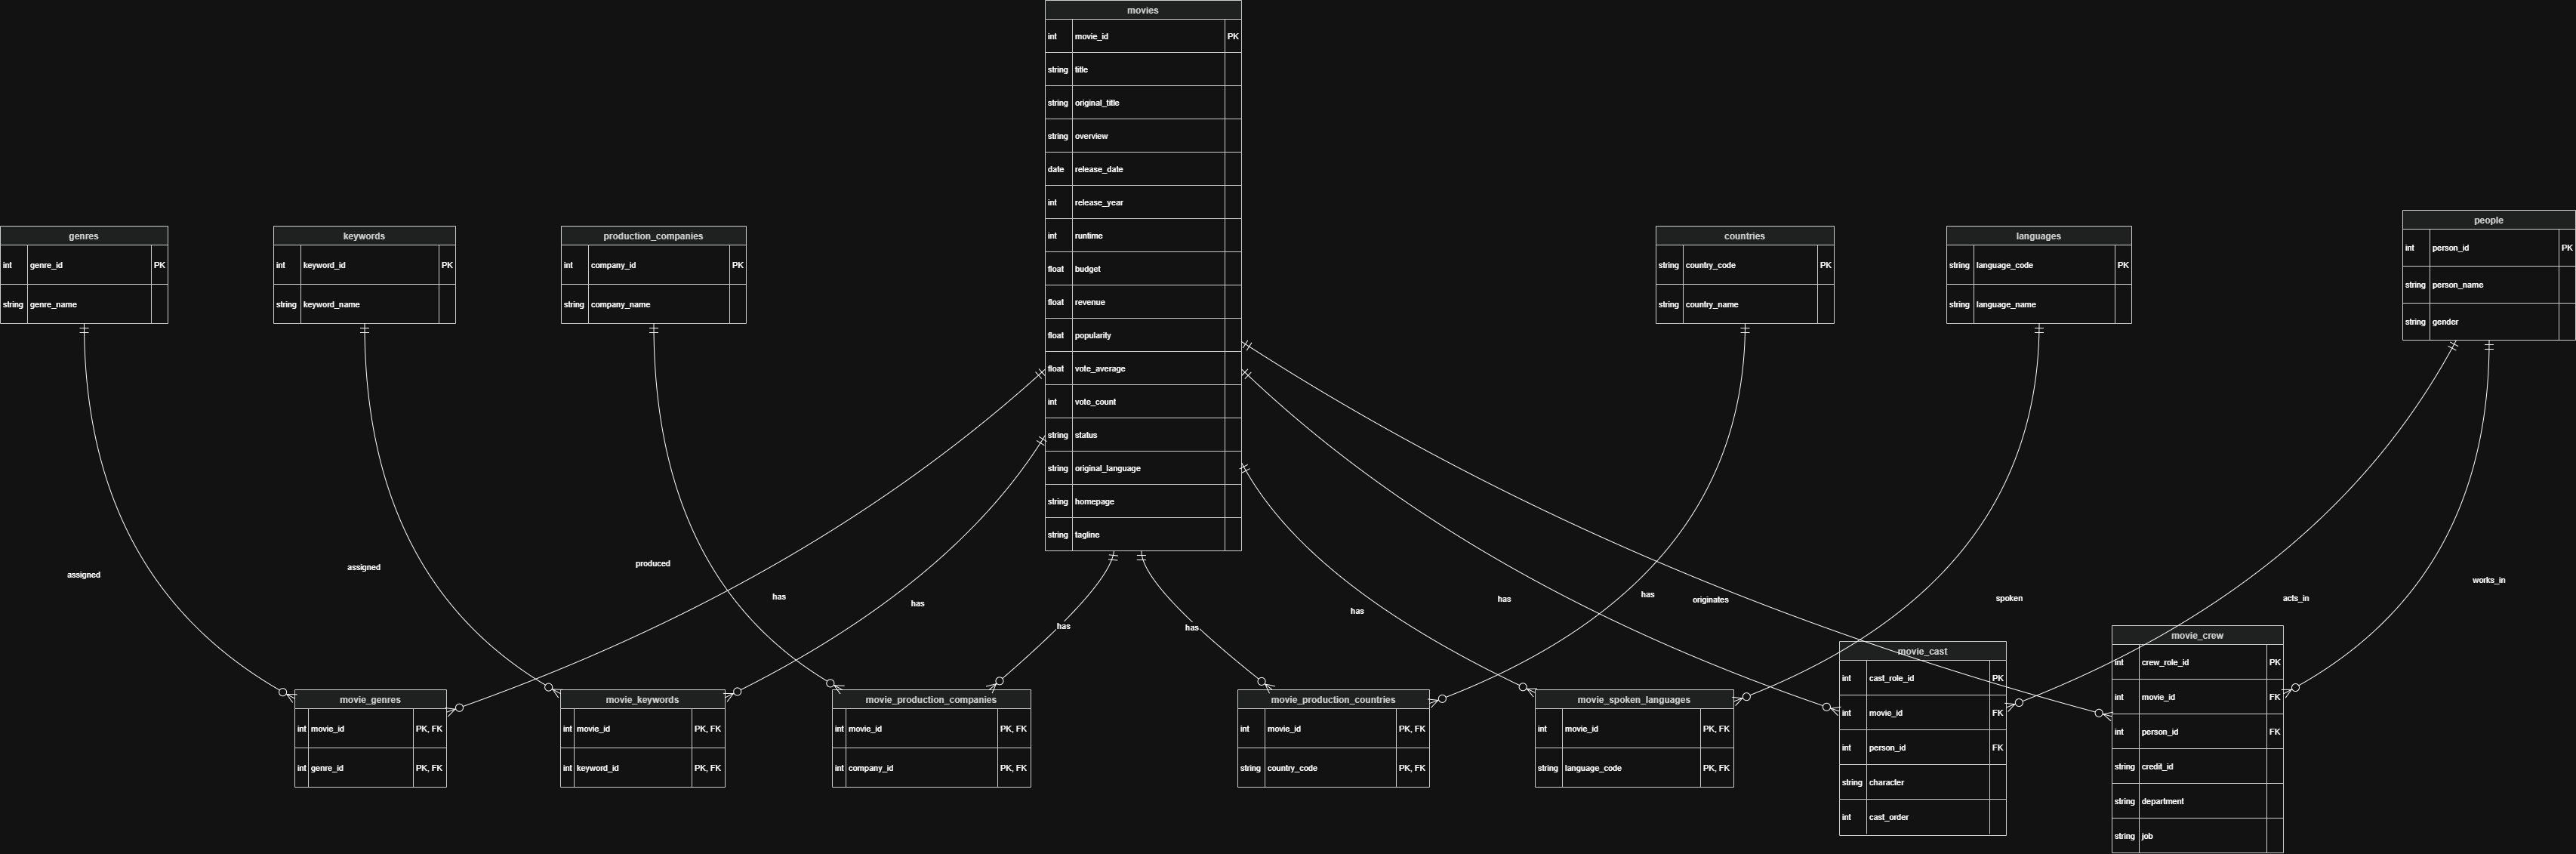

## Fase 3: Implementación Técnica (Python & SQL)

### ETL: Extract, Transform, Load

En esta fase se aplica el proceso ETL utilizando Python y Pandas. Primero se extraen los datos desde los archivos CSV originales del dataset TMDB 5000. Luego, se transforman las columnas multivaluadas en formato JSON para crear tablas normalizadas según el diseño de la Fase 2. Finalmente, las tablas resultantes se cargan en una base de datos SQLite llamada `tmdb_normalized.db`.

El proceso ETL se divide en:

- **Extract:** lectura de los archivos `tmdb_5000_movies.csv` y `tmdb_5000_credits.csv`.
- **Transform:** creación de tablas normalizadas, tablas maestras y tablas puente.
- **Load:** creación de la base de datos SQLite y carga de los DataFrames normalizados.

In [12]:
# EXTRACT
movies_path = input_dir / "tmdb_5000_movies.csv"
credits_path = input_dir / "tmdb_5000_credits.csv"

movies = pd.read_csv(movies_path)
credits = pd.read_csv(credits_path)

print("Movies dataset:", movies.shape)
print("Credits dataset:", credits.shape)

display(movies.head(3))
display(credits.head(3))

Movies dataset: (4803, 20)
Credits dataset: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [13]:
# TRANSFORM
# Creamos la tabla principal movies

movies_clean = movies.rename(columns={"id": "movie_id"}).copy()

# Convertimos release_date a formato fecha
movies_clean["release_date"] = pd.to_datetime(
    movies_clean["release_date"], 
    errors="coerce"
)

# Extraemos el año de estreno
movies_clean["release_year"] = movies_clean["release_date"].dt.year

# Seleccionamos las columnas atómicas para la tabla movies
movies_table = movies_clean[
    [
        "movie_id",
        "title",
        "original_title",
        "overview",
        "release_date",
        "release_year",
        "runtime",
        "budget",
        "revenue",
        "popularity",
        "vote_average",
        "vote_count",
        "status",
        "original_language",
        "homepage",
        "tagline"
    ]
].copy()

# Convertimos la fecha a texto para SQLite
movies_table["release_date"] = movies_table["release_date"].dt.strftime("%Y-%m-%d")

print("Tabla movies creada:")
print(movies_table.shape)

display(movies_table.head())

Tabla movies creada:
(4803, 16)


,movie_id,title,original_title,overview,release_date,release_year,runtime,budget,revenue,popularity,vote_average,vote_count,status,original_language,homepage,tagline
0,19995,Avatar,Avatar,"In the 22nd century, a paraplegic Marine is di...",2009-12-10,2009.0,162.0,237000000,2787965087,150.437577,7.2,11800,Released,en,http://www.avatarmovie.com/,Enter the World of Pandora.
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",2007-05-19,2007.0,169.0,300000000,961000000,139.082615,6.9,4500,Released,en,http://disney.go.com/disneypictures/pirates/,"At the end of the world, the adventure begins."
2,206647,Spectre,Spectre,A cryptic message from Bond’s past sends him o...,2015-10-26,2015.0,148.0,245000000,880674609,107.376788,6.3,4466,Released,en,http://www.sonypictures.com/movies/spectre/,A Plan No One Escapes
3,49026,The Dark Knight Rises,The Dark Knight Rises,Following the death of District Attorney Harve...,2012-07-16,2012.0,165.0,250000000,1084939099,112.312950,7.6,9106,Released,en,http://www.thedarkknightrises.com/,The Legend Ends
4,49529,John Carter,John Carter,"John Carter is a war-weary, former military ca...",2012-03-07,2012.0,132.0,260000000,284139100,43.926995,6.1,2124,Released,en,http://movies.disney.com/john-carter,"Lost in our world, found in another."


### Transformación de columnas JSON en tablas catálogo y puente

Después de crear la tabla principal `movies` usando los datos del archivo "tmdb_5000_movies.csv", se procesan las columnas que contienen listas JSON. Estas columnas representan relaciones muchos a muchos, por lo que se separan en tablas catálogo y puente.

Las columnas procesadas en esta etapa son:

- `genres`
- `keywords`
- `production_companies`
- `production_countries`
- `spoken_languages`

Cada tabla catálogo guarda los valores únicos, mientras que cada tabla puente conecta esos valores con las películas.

In [14]:
# Función para convertir strings JSON en listas de diccionarios

def parse_json_list(value):
    if pd.isna(value):
        return []
    
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
        return []
    except Exception:
        return []


# Función para crear una tabla catálogo y una tabla puente desde columnas JSON

def make_catalog_and_bridge(
    df,
    json_col,
    catalog_id_col,
    catalog_name_col,
    bridge_id_col,
    id_key,
    name_key
):
    catalog_rows = []
    bridge_rows = []

    for _, row in df.iterrows():
        movie_id = int(row["id"])

        for item in parse_json_list(row[json_col]):
            item_id = item.get(id_key)
            item_name = item.get(name_key)

            if item_id is None or item_id == "":
                continue

            catalog_rows.append({
                catalog_id_col: item_id,
                catalog_name_col: item_name
            })

            bridge_rows.append({
                "movie_id": movie_id,
                bridge_id_col: item_id
            })

    catalog_df = pd.DataFrame(catalog_rows).drop_duplicates(subset=[catalog_id_col])
    bridge_df = pd.DataFrame(bridge_rows).drop_duplicates()

    return catalog_df, bridge_df

In [15]:
# Crear tablas catálogo y tablas puente desde las columnas JSON de movies

genres, movie_genres = make_catalog_and_bridge(
    movies,
    "genres",
    "genre_id",
    "genre_name",
    "genre_id",
    "id",
    "name"
)

keywords, movie_keywords = make_catalog_and_bridge(
    movies,
    "keywords",
    "keyword_id",
    "keyword_name",
    "keyword_id",
    "id",
    "name"
)

production_companies, movie_production_companies = make_catalog_and_bridge(
    movies,
    "production_companies",
    "company_id",
    "company_name",
    "company_id",
    "id",
    "name"
)

countries, movie_production_countries = make_catalog_and_bridge(
    movies,
    "production_countries",
    "country_code",
    "country_name",
    "country_code",
    "iso_3166_1",
    "name"
)

languages, movie_spoken_languages = make_catalog_and_bridge(
    movies,
    "spoken_languages",
    "language_code",
    "language_name",
    "language_code",
    "iso_639_1",
    "name"
)

print("Tablas creadas desde columnas JSON de movies:")

print("genres:", genres.shape)
print("movie_genres:", movie_genres.shape)

print("keywords:", keywords.shape)
print("movie_keywords:", movie_keywords.shape)

print("production_companies:", production_companies.shape)
print("movie_production_companies:", movie_production_companies.shape)

print("countries:", countries.shape)
print("movie_production_countries:", movie_production_countries.shape)

print("languages:", languages.shape)
print("movie_spoken_languages:", movie_spoken_languages.shape)

display(genres.head())
display(movie_genres.head())
display(languages.head())
display(movie_spoken_languages.head())

Tablas creadas desde columnas JSON de movies:
genres: (20, 2)
movie_genres: (12160, 2)
keywords: (9813, 2)
movie_keywords: (36194, 2)
production_companies: (5047, 2)
movie_production_companies: (13677, 2)
countries: (88, 2)
movie_production_countries: (6436, 2)
languages: (87, 2)
movie_spoken_languages: (6937, 2)


,genre_id,genre_name
0,28,Action
1,12,Adventure
2,14,Fantasy
3,878,Science Fiction
9,80,Crime


,movie_id,genre_id
0,19995,28
1,19995,12
2,19995,14
3,19995,878
4,285,12


,language_code,language_name
0,en,English
1,es,Español
3,fr,Français
6,it,Italiano
7,de,Deutsch


,movie_id,language_code
0,19995,en
1,19995,es
2,285,en
3,206647,fr
4,206647,en


### Transformación de credits

Después de procesar las columnas JSON del archivo `movies`, se procesa el archivo `credits`. Este archivo contiene información del (cast) y del (crew) en formato JSON.

Para poder normalizar estos datos, se crea una tabla `people`, donde se almacenara las personas únicas, y dos tablas puente siendo:

- `movie_cast`: conecta películas con actores y personajes.
- `movie_crew`: conecta películas con miembros del equipo técnico y sus trabajos.

Esto evita repetir información de personas y mantiene separadas las relaciones multivaluadas de actores y equipo técnico.

In [16]:
# Creamos las tablas (people, movie_cast y movie_crew) usando los datos en el archivo credits

people_rows = []
cast_rows = []
crew_rows = []

for _, row in credits.iterrows():
    movie_id = int(row["movie_id"])

    # Procesamos cast
    for actor in parse_json_list(row["cast"]):
        person_id = actor.get("id")
        
        if person_id is None:
            continue

        people_rows.append({
            "person_id": person_id,
            "person_name": actor.get("name"),
            "gender": actor.get("gender")
        })

        cast_rows.append({
            "movie_id": movie_id,
            "person_id": person_id,
            "character": actor.get("character"),
            "cast_order": actor.get("order")
        })

    # Procesamos crew
    for member in parse_json_list(row["crew"]):
        person_id = member.get("id")
        
        if person_id is None:
            continue

        people_rows.append({
            "person_id": person_id,
            "person_name": member.get("name"),
            "gender": member.get("gender")
        })

        crew_rows.append({
            "movie_id": movie_id,
            "person_id": person_id,
            "credit_id": member.get("credit_id"),
            "department": member.get("department"),
            "job": member.get("job")
        })

people = pd.DataFrame(people_rows).drop_duplicates(subset=["person_id"])
movie_cast = pd.DataFrame(cast_rows).drop_duplicates()
movie_crew = pd.DataFrame(crew_rows).drop_duplicates()

# Aqui creamos las llaves primarias artificiales para las tablas de roles
movie_cast.insert(0, "cast_role_id", range(1, len(movie_cast) + 1))
movie_crew.insert(0, "crew_role_id", range(1, len(movie_crew) + 1))

print("people:", people.shape)
print("movie_cast:", movie_cast.shape)
print("movie_crew:", movie_crew.shape)

display(people.head())
display(movie_cast.head())
display(movie_crew.head())

people: (104842, 3)
movie_cast: (106257, 5)
movie_crew: (129581, 6)


,person_id,person_name,gender
0,65731,Sam Worthington,2
1,8691,Zoe Saldana,1
2,10205,Sigourney Weaver,1
3,32747,Stephen Lang,2
4,17647,Michelle Rodriguez,1


,cast_role_id,movie_id,person_id,character,cast_order
0,1,19995,65731,Jake Sully,0
1,2,19995,8691,Neytiri,1
2,3,19995,10205,Dr. Grace Augustine,2
3,4,19995,32747,Col. Quaritch,3
4,5,19995,17647,Trudy Chacon,4


,crew_role_id,movie_id,person_id,credit_id,department,job
0,1,19995,1721,52fe48009251416c750aca23,Editing,Editor
1,2,19995,496,539c47ecc3a36810e3001f87,Art,Production Design
2,3,19995,900,54491c89c3a3680fb4001cf7,Sound,Sound Designer
3,4,19995,900,54491cb70e0a267480001bd0,Sound,Supervising Sound Editor
4,5,19995,1262,539c4a4cc3a36810c9002101,Production,Casting


### Load: creación de la base de datos SQLite

En esta etapa se creara el archivo `tmdb_normalized.db` usando SQLite. Luego se definen las tablas con sus llaves primarias y foráneas para mantener la integridad referencial.

A lo ultimo, los DataFrames normalizados creados en la etapa de transformación se cargan en sus respectivas tablas SQL.

In [17]:
# LOAD
# Crear base de datos SQLite con tablas, PK y FK

db_path = "/kaggle/working/tmdb_normalized.db"

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")

# Borramos las tablas que ya existen para poder correr varias veces
drop_order = [
    "movie_crew",
    "movie_cast",
    "movie_spoken_languages",
    "movie_production_countries",
    "movie_production_companies",
    "movie_keywords",
    "movie_genres",
    "people",
    "languages",
    "countries",
    "production_companies",
    "keywords",
    "genres",
    "movies"
]

for table in drop_order:
    cursor.execute(f"DROP TABLE IF EXISTS {table};")

schema_sql = """
CREATE TABLE movies (
    movie_id INTEGER PRIMARY KEY,
    title TEXT NOT NULL,
    original_title TEXT,
    overview TEXT,
    release_date TEXT,
    release_year INTEGER,
    runtime REAL,
    budget INTEGER,
    revenue INTEGER,
    popularity REAL,
    vote_average REAL,
    vote_count INTEGER,
    status TEXT,
    original_language TEXT,
    homepage TEXT,
    tagline TEXT
);

CREATE TABLE genres (
    genre_id INTEGER PRIMARY KEY,
    genre_name TEXT NOT NULL
);

CREATE TABLE movie_genres (
    movie_id INTEGER NOT NULL,
    genre_id INTEGER NOT NULL,
    PRIMARY KEY (movie_id, genre_id),
    FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY (genre_id) REFERENCES genres(genre_id)
);

CREATE TABLE keywords (
    keyword_id INTEGER PRIMARY KEY,
    keyword_name TEXT NOT NULL
);

CREATE TABLE movie_keywords (
    movie_id INTEGER NOT NULL,
    keyword_id INTEGER NOT NULL,
    PRIMARY KEY (movie_id, keyword_id),
    FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY (keyword_id) REFERENCES keywords(keyword_id)
);

CREATE TABLE production_companies (
    company_id INTEGER PRIMARY KEY,
    company_name TEXT
);

CREATE TABLE movie_production_companies (
    movie_id INTEGER NOT NULL,
    company_id INTEGER NOT NULL,
    PRIMARY KEY (movie_id, company_id),
    FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY (company_id) REFERENCES production_companies(company_id)
);

CREATE TABLE countries (
    country_code TEXT PRIMARY KEY,
    country_name TEXT
);

CREATE TABLE movie_production_countries (
    movie_id INTEGER NOT NULL,
    country_code TEXT NOT NULL,
    PRIMARY KEY (movie_id, country_code),
    FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY (country_code) REFERENCES countries(country_code)
);

CREATE TABLE languages (
    language_code TEXT PRIMARY KEY,
    language_name TEXT
);

CREATE TABLE movie_spoken_languages (
    movie_id INTEGER NOT NULL,
    language_code TEXT NOT NULL,
    PRIMARY KEY (movie_id, language_code),
    FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY (language_code) REFERENCES languages(language_code)
);

CREATE TABLE people (
    person_id INTEGER PRIMARY KEY,
    person_name TEXT,
    gender INTEGER
);

CREATE TABLE movie_cast (
    cast_role_id INTEGER PRIMARY KEY,
    movie_id INTEGER NOT NULL,
    person_id INTEGER NOT NULL,
    character TEXT,
    cast_order INTEGER,
    FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY (person_id) REFERENCES people(person_id)
);

CREATE TABLE movie_crew (
    crew_role_id INTEGER PRIMARY KEY,
    movie_id INTEGER NOT NULL,
    person_id INTEGER NOT NULL,
    credit_id TEXT,
    department TEXT,
    job TEXT,
    FOREIGN KEY (movie_id) REFERENCES movies(movie_id),
    FOREIGN KEY (person_id) REFERENCES people(person_id)
);
"""

cursor.executescript(schema_sql)
conn.commit()
#Verficamos
print("Base de datos y tablas creadas correctamente.")

Base de datos y tablas creadas correctamente.


### Carga de DataFrames a SQLite

En esta parte se cargan los DataFrames normalizados a la base de datos SQLite. Cada DataFrame representa una tabla del modelo relacional final.

Primero se cargan las tablas principales y maestras, como `movies`, `genres`, `keywords`, `countries`, `languages` y `people`. Luego se cargan las tablas puente, como `movie_genres`, `movie_keywords`, `movie_cast` y `movie_crew`.

La función `insert_df()` se utiliza para insertar cada DataFrame en su tabla correspondiente dentro de SQLite. También convierte valores nulos de Pandas a valores compatibles con SQL.

In [18]:
# Cargar DataFrames normalizados a SQLite

def insert_df(df, table_name):
    df = df.where(pd.notnull(df), None)
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"{table_name}: {len(df)} filas insertadas")


# Tablas Maestras
insert_df(movies_table, "movies")
insert_df(genres, "genres")
insert_df(keywords, "keywords")
insert_df(production_companies, "production_companies")
insert_df(countries, "countries")
insert_df(languages, "languages")
insert_df(people, "people")

# Tablas Puentes
insert_df(movie_genres, "movie_genres")
insert_df(movie_keywords, "movie_keywords")
insert_df(movie_production_companies, "movie_production_companies")
insert_df(movie_production_countries, "movie_production_countries")
insert_df(movie_spoken_languages, "movie_spoken_languages")
insert_df(movie_cast, "movie_cast")
insert_df(movie_crew, "movie_crew")

conn.commit()

print("Base de datos creada en:", db_path)

movies: 4803 filas insertadas
genres: 20 filas insertadas
keywords: 9813 filas insertadas
production_companies: 5047 filas insertadas
countries: 88 filas insertadas
languages: 87 filas insertadas
people: 104842 filas insertadas
movie_genres: 12160 filas insertadas
movie_keywords: 36194 filas insertadas
movie_production_companies: 13677 filas insertadas
movie_production_countries: 6436 filas insertadas
movie_spoken_languages: 6937 filas insertadas
movie_cast: 106257 filas insertadas
movie_crew: 129581 filas insertadas
Base de datos creada en: /kaggle/working/tmdb_normalized.db


### Verificación de tablas cargadas

Después de cargar los datos, se verifica que las tablas hayan sido creadas correctamente en la base de datos SQLite.

El siguiente código consulta la base de datos para mostrar la lista de tablas existentes y luego cuenta cuántas filas tiene cada tabla. Esto es para confirmar que el proceso de carga fue exitoso y que los datos normalizados fueron insertados en sus respectivas tablas.

In [19]:
# Verificamos que las tablas se crearon y cargaron correctamente

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn
)

display(tables)

for table in tables["name"]:
    count = pd.read_sql_query(f"SELECT COUNT(*) AS total FROM {table};", conn)
    print(f"{table}: {count['total'].iloc[0]} filas")

,name
0,countries
1,genres
2,keywords
3,languages
4,movie_cast
5,movie_crew
6,movie_genres
7,movie_keywords
8,movie_production_companies
9,movie_production_countries


countries: 88 filas
genres: 20 filas
keywords: 9813 filas
languages: 87 filas
movie_cast: 106257 filas
movie_crew: 129581 filas
movie_genres: 12160 filas
movie_keywords: 36194 filas
movie_production_companies: 13677 filas
movie_production_countries: 6436 filas
movie_spoken_languages: 6937 filas
movies: 4803 filas
people: 104842 filas
production_companies: 5047 filas
